In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:


from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)

In [135]:
X = heart_disease.data.features
y = heart_disease.data.targets



In [136]:
print(X.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


## Explanations of all the columns: 
This dataset is for the heart disease dataset in which we test for people having heart disease
1. chol means cholestrol levels of the person 
2. fbs — fasting blood sugar > 120 mg/dl. 1 = true, 0 = false. Indicates diabetes risk.
3. restecg — resting ECG results. 0=normal, 1=ST-T wave abnormality, 2=left ventricular hypertrophy.
4. thalach — maximum heart rate achieved during stress test. Lower max heart rate can indicate heart problems.
5. cp (chest pain type) — 4 categories: 1=typical angina, 2=atypical angina, 3=non-anginal pain, 4=asymptomatic. these are different types of chest pain each shows something different
6. exang - exercise induced angina means does the person feel chest pain during or after exercise
7. oldpeak — ST depression induced by exercise relative to rest. Higher values indicate more stress on the heart.
8. slope — slope of peak exercise ST segment. 1=upsloping, 2=flat, 3=downsloping.
9. ca — number of major vessels (0-3) colored by fluoroscopy. More blocked vessels = higher disease severity. Has missing values.
10. thal — thalassemia blood disorder. 3=normal, 6=fixed defect, 7=reversible defect. Has missing values.
11. num (target) — 0 = no heart disease, 1-4 = presence of heart disease with increasing severity
12. The column trestbps means the resting blood pressure of the person when admitted to the hospital

In [137]:
# first we will see the types of all of the columns 
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


Here we have total 12 columns in which cp,sex,fbs,restecg,exang,slope,ca and thal are categorical and the rest like age,trestbps,chol,thalach and oldpeak are numerical

In [138]:
# lets see few rows of the data
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [139]:
# also we can see the description of the data 
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


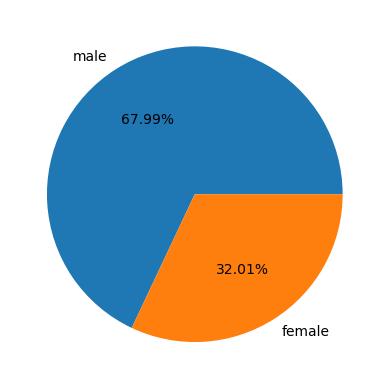

In [140]:
# here mean of sex is higher than 0.5 it may suggest that data consists more male than female
pieplot_ = X.sex.value_counts()
plt.pie(x = pieplot_.values,labels = ['male','female'],autopct = "%.2f%%")
plt.show()

### Observation: 
As you can see here the data consists of 68% males and 32 % females. 


(array([  0.,   0.,   1.,  14.,  72., 125.,  81.,  10.]),
 array([ 0., 10., 20., 30., 40., 50., 60., 70., 80.]),
 <BarContainer object of 8 artists>)

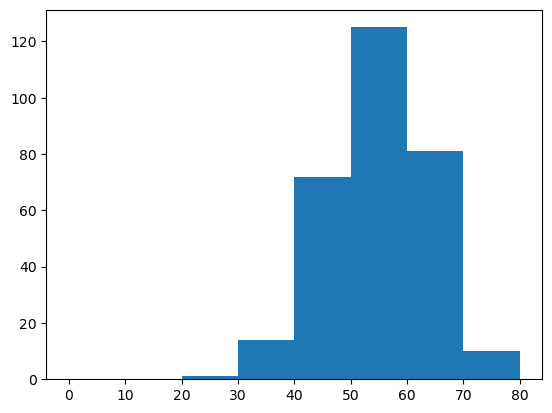

In [141]:
# lets do this for age to lets plot a histogram as the max age is 77 we will include till 80 

plt.hist(x = X['age'],bins=[0,10,20,30,40,50,60,70,80])

As we can see here maximum people here are in the range of 50 -60 whereas almost all of the data lies between 40 to 70.

In [142]:
# this can be done for all the features in order to see where does the data lie but now we will move to correlations but first we need to change the y labels from 0,1,2,3,4 to 0 or 1
def function(row):
    if row >=1:
        return 1
    else:
        return 0

y['num'] = y['num'].apply(function)


/var/folders/vd/q7bl10xx6dn2w6n3_2t5l87w0000gn/T/ipykernel_2334/1402798125.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['num'] = y['num'].apply(function)


In [143]:
print(y.value_counts())



num
0      164
1      139
Name: count, dtype: int64


In [144]:
df= pd.concat((X,y),axis=1)

In [145]:
print(df)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  num  
0        3  0.0   6.0    0  
1        2  3.0   3.0    1  


now we will see correlations:

In [146]:
print(df.corr())

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.097542  0.104139  0.284946  0.208950  0.118530   
sex      -0.097542  1.000000  0.010084 -0.064456 -0.199915  0.047862   
cp        0.104139  0.010084  1.000000 -0.036077  0.072319 -0.039975   
trestbps  0.284946 -0.064456 -0.036077  1.000000  0.130120  0.175340   
chol      0.208950 -0.199915  0.072319  0.130120  1.000000  0.009841   
fbs       0.118530  0.047862 -0.039975  0.175340  0.009841  1.000000   
restecg   0.148868  0.021647  0.067505  0.146560  0.171043  0.069564   
thalach  -0.393806 -0.048663 -0.334422 -0.045351 -0.003432 -0.007854   
exang     0.091661  0.146201  0.384060  0.064762  0.061310  0.025665   
oldpeak   0.203805  0.102173  0.202277  0.189171  0.046564  0.005747   
slope     0.161770  0.037533  0.152050  0.117382 -0.004062  0.059894   
ca        0.362605  0.093185  0.233214  0.098773  0.119000  0.145478   
thal      0.127389  0.380936  0.265246  0.133554  0.014214  0.07

In [150]:
# these are all correlations
series = df.iloc[:,:-1].corrwith(df.loc[:,'num'])

series.index = df.columns[:-1]

series = abs(series)

# the highest five correlations
print(series.sort_values(ascending=False))
# the five most import columns


thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach     0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
dtype: float64


As here you can see the highest correlations are with thal,ca,exang,oldpeak,thalach and with cp. These are said to be the most important features of all.


<Axes: xlabel='thal', ylabel='no of people'>

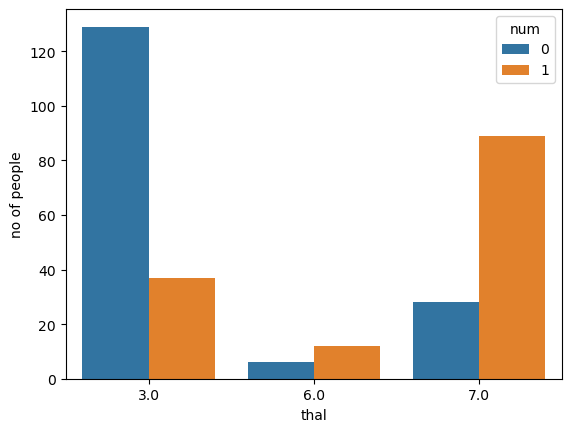

In [151]:
# plotting with the highly correlated features plt.scatter 
# to show correlation with the thal i will need to colour by bar due to thal

thanos=df.groupby(['thal','num']).size().reset_index().rename({0:"no of people"},axis=1)

sns.barplot(x = 'thal',y = 'no of people',hue = 'num',data = thanos)

## Observation: 
here we can clearly see that higher thal is higher is the chances of disease approximately.

<Axes: xlabel='ca', ylabel='no of people'>

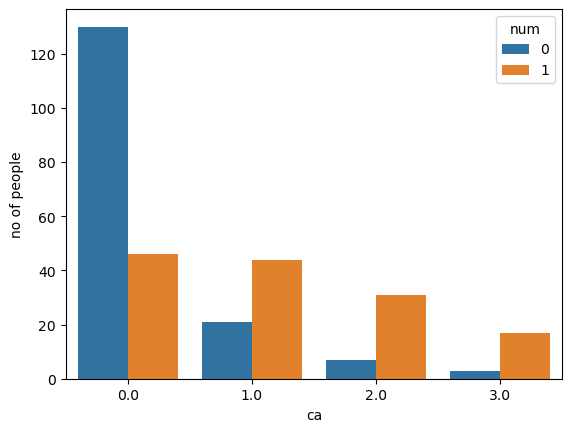

In [152]:
thanos=df.groupby(['ca','num']).size().reset_index().rename({0:"no of people"},axis=1)

sns.barplot(x = 'ca',y = 'no of people',hue = 'num',data = thanos)

<Axes: xlabel='exang', ylabel='no of people'>

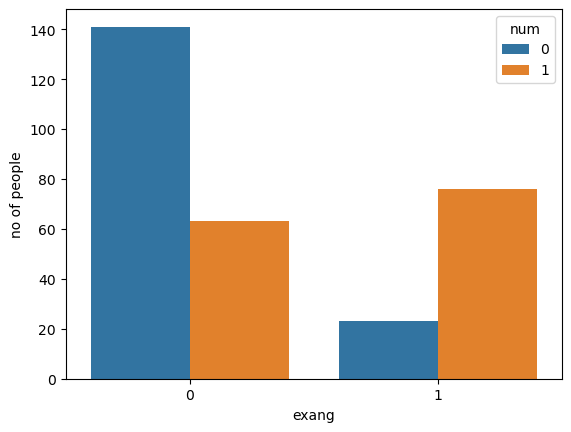

In [153]:
thanos=df.groupby(['exang','num']).size().reset_index().rename({0:"no of people"},axis=1)

sns.barplot(x = 'exang',y = 'no of people',hue = 'num',data = thanos)

<Axes: xlabel='oldpeak', ylabel='Count'>

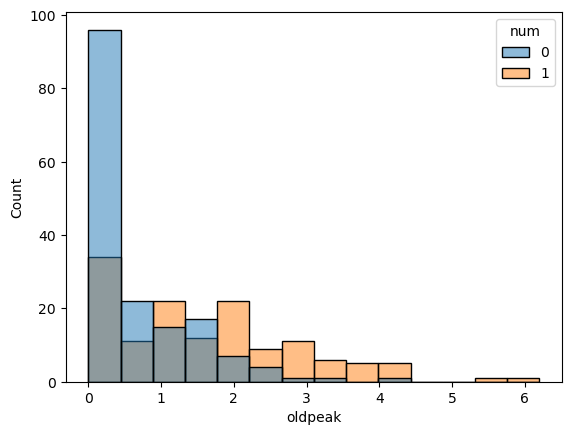

In [154]:

sns.histplot(x = df['oldpeak'],hue = df['num'])

<Axes: xlabel='thalach', ylabel='Count'>

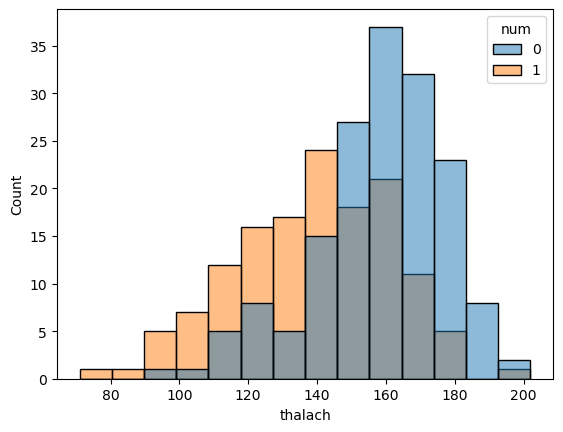

In [155]:
# how can i show correlation with plots
sns.histplot(x = df['thalach'],hue = df['num'])

## These are all of the plots.

## Handling Missing values now


In [156]:
print(df.isna().sum())
# There are only 6 null values here 
# since ca is categorical we will fill by mode

X['ca'].fillna(X['ca'].mode()[0],inplace = True)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


/var/folders/vd/q7bl10xx6dn2w6n3_2t5l87w0000gn/T/ipykernel_2334/1035990103.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['ca'].fillna(X['ca'].mode()[0],inplace = True)
/var/folders/vd/q7bl10xx6dn2w6n3_2t5l87w0000gn/T/ipykernel_2334/1035990103.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['ca'].fillna(X['ca'].mode()[0],inplace =

In [157]:
print(X.isna().sum())
# thal is also categorical 



age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        2
dtype: int64


In [158]:
X['thal'].fillna(X['thal'].mode()[0],inplace = True)

/var/folders/vd/q7bl10xx6dn2w6n3_2t5l87w0000gn/T/ipykernel_2334/2346830384.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['thal'].fillna(X['thal'].mode()[0],inplace = True)
/var/folders/vd/q7bl10xx6dn2w6n3_2t5l87w0000gn/T/ipykernel_2334/2346830384.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['thal'].fillna(X['thal'].mode()[0],i

In [159]:

print(X.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


# Final Summary: 
Here we first saw there are around 8 categorical and 4 numerical values. We also found out the most important features which are thal,ca,exang,oldpeak,thalach and with cp. Here primarily the data is very less as there are only 303 rows of data.Also The data is 68 % male and 32 % female. Also it is primarily of people in their 50s. There can be also more columns in order to take in care other health details as well but there are also columns that have very less correlation like fbs and cholestrol. Also the targets after being converted to binary are 168 no disease ones and 135 disease ones. They are roughly equal so there will not be a big problem but the model can be more leaned towards detecting no disease than disease.